# Assignment 2 -- Train the Full Hierarchical MDN VAE

In this assignment you train the complete model -- Hierarchical VAE with an MDN output head -- and evaluate its ability to generate diverse completions.

**What you need to submit:**
- Trained HierarchicalMDNVAE on a non-cat category (20+ epochs)
- Loss curves (NLL, pen, KL)
- 4 diverse completions from the same starting context
- Temperature experiment
- Answers to reflection questions

**Target:** Checkpoint 4 -- multiple unique completions for the same starting line.

## Step 1 -- Load your category and define the full model

In [15]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, json, os
import matplotlib.pyplot as plt
import urllib.request
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

category = 'bed'   # TODO: change to your category

# TODO: Paste drawing_to_stroke5, normalise_stroke5, QuickDrawDataset, collate_fn
# YOUR CODE HERE
def drawing_to_stroke5(drawing, max_len=200):
    strokes = []
    for stroke in drawing:
        xs, ys = stroke[0], stroke[1]
        for i in range(len(xs)):
            dx = xs[i] - xs[i-1] if i > 0 else 0
            dy = ys[i] - ys[i-1] if i > 0 else 0
            if i < len(xs) - 1: p1, p2, p3 = 1, 0, 0
            else: p1, p2, p3 = 0, 1, 0
            strokes.append([dx, dy, p1, p2, p3])
    strokes.append([0, 0, 0, 0, 1])
    s5 = np.array(strokes, dtype=np.float32)
    if len(s5) > max_len:
        s5 = s5[:max_len]; s5[-1] = [0, 0, 0, 0, 1]
    return s5

def normalise_stroke5(stroke5):
    s = stroke5.copy()
    coords = s[:, :2]
    s[:, :2] = (coords - coords.mean(axis=0)) / (coords.std(axis=0) + 1e-8)
    return s

class QuickDrawDataset(Dataset):
    def __init__(self, path, max_len=200, max_samples=5000):
        self.samples = []
        with open(path) as f:
            for i, line in enumerate(f):
                if i >= max_samples: break
                d = json.loads(line)
                s5 = drawing_to_stroke5(d['drawing'], max_len=max_len)
                s5 = normalise_stroke5(s5)
                self.samples.append(torch.tensor(s5, dtype=torch.float32))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]

def collate_fn(batch):
    lengths = [seq.shape[0] for seq in batch]
    padded  = pad_sequence(batch, batch_first=True, padding_value=0.0)
    return padded, lengths

os.makedirs('data', exist_ok=True)
path = 'data/bed.ndjson'
if not os.path.exists(path):
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/quickdraw_dataset/full/simplified/bed.ndjson', path)

dataset = QuickDrawDataset(path, max_len=200, max_samples=3000)
loader  = DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)

# TODO: Paste Encoder, reparameterise, Conductor, MDNHead, WorkerMDN, HierarchicalMDNVAE
# YOUR CODE HERE
class Encoder(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=256, latent_dim=128):
        super().__init__()
        self.lstm      = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc_mu     = nn.Linear(hidden_dim * 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim * 2, latent_dim)

    def forward(self, x, lengths):
        packed = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)
        h = torch.cat([h[0], h[1]], dim=-1)
        return self.fc_mu(h), self.fc_logvar(h)

def reparameterise(mu, logvar):
    return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

class Conductor(nn.Module):
    def __init__(self, latent_dim=128, conductor_dim=512, output_dim=256, num_segments=16):
        super().__init__()
        self.num_segments = num_segments
        self.output_dim   = output_dim
        self.fc_init = nn.Linear(latent_dim, conductor_dim)
        self.lstm    = nn.LSTM(output_dim, conductor_dim, batch_first=True)
        self.fc_out  = nn.Linear(conductor_dim, output_dim)
    def forward(self, z):
        batch = z.shape[0]
        h = torch.tanh(self.fc_init(z)).unsqueeze(0)
        c = torch.zeros_like(h)
        inp = torch.zeros(batch, 1, self.output_dim, device=z.device)
        outs = []
        for _ in range(self.num_segments):
            out, (h, c) = self.lstm(inp, (h, c))
            cv = self.fc_out(out); outs.append(cv); inp = cv
        return torch.cat(outs, dim=1)
    
class MDNHead(nn.Module):
    def __init__(self, input_dim, num_mixtures=20):
        '''
        input_dim    : size of the LSTM output
        num_mixtures : number of Gaussian components K
        '''
        super().__init__()
        self.K = num_mixtures
        # Predict: pi (K), mu_x (K), mu_y (K), sigma_x (K), sigma_y (K), rho (K)
        self.fc = nn.Linear(input_dim, num_mixtures * 6)

    def forward(self, h):
        '''
        h : LSTM hidden output, shape (batch, seq_len, input_dim)
        Returns a dict of mixture parameters, each shape (batch, seq_len, K)
        '''
        out = self.fc(h)   # (batch, seq_len, K*6)
        K   = self.K

        pi    = F.softmax(out[..., :K],         dim=-1)            # mixing weights sum to 1
        mu_x  = out[..., K:2*K]
        mu_y  = out[..., 2*K:3*K]
        sig_x = torch.exp(out[..., 3*K:4*K])                      # must be positive
        sig_y = torch.exp(out[..., 4*K:5*K])
        rho   = torch.tanh(out[..., 5*K:6*K])                     # between -1 and 1

        return {'pi': pi, 'mu_x': mu_x, 'mu_y': mu_y,
                'sig_x': sig_x, 'sig_y': sig_y, 'rho': rho}

# Quick test
head = MDNHead(input_dim=512, num_mixtures=20)
dummy_h = torch.randn(4, 100, 512)   # (batch, seq_len, worker_dim)
params = head(dummy_h)
print('pi shape   :', params['pi'].shape)    # (4, 100, 20)
print('mu_x shape :', params['mu_x'].shape)

class WorkerMDN(nn.Module):
    def __init__(self, input_dim=5, conductor_out_dim=256,
                 worker_dim=512, num_mixtures=20, num_pen_states=3):
        super().__init__()
        self.lstm    = nn.LSTM(input_dim + conductor_out_dim, worker_dim, batch_first=True)
        self.mdn     = MDNHead(worker_dim, num_mixtures)
        self.fc_pen  = nn.Linear(worker_dim, num_pen_states)   # separate head for pen state

    def forward(self, stroke_seq, c_seq, segment_len):
        batch, seq_len, _ = stroke_seq.shape
        c_exp = c_seq.repeat_interleave(segment_len, dim=1)[:, :seq_len, :]
        worker_in = torch.cat([stroke_seq, c_exp], dim=-1)
        h, _ = self.lstm(worker_in)
        mdn_params = self.mdn(h)
        pen_logits = self.fc_pen(h)   # (batch, seq_len, 3)
        return mdn_params, pen_logits

class HierarchicalMDNVAE(nn.Module):
    def __init__(self, input_dim=5, latent_dim=128, num_segments=16, num_mixtures=20):
        super().__init__()
        self.num_segments = num_segments
        self.encoder   = Encoder(input_dim, 256, latent_dim)
        self.conductor = Conductor(latent_dim, 512, 256, num_segments)
        self.worker    = WorkerMDN(input_dim, 256, 512, num_mixtures)

    def forward(self, x, lengths):
        mu, logvar = self.encoder(x, lengths)
        z          = reparameterise(mu, logvar)
        c_seq      = self.conductor(z)
        start      = torch.zeros(x.shape[0], 1, x.shape[2], device=x.device)
        dec_in     = torch.cat([start, x[:, :-1, :]], dim=1)
        seg_len    = x.shape[1] // self.num_segments + 1
        mdn_params, pen_logits = self.worker(dec_in, c_seq, seg_len)
        return mdn_params, pen_logits, mu, logvar

model = HierarchicalMDNVAE()
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

padded, lengths = next(iter(loader))
mdn_params, pen_logits, mu, logvar = model(padded, lengths)
print('pi shape      :', mdn_params['pi'].shape)
print('pen_logits    :', pen_logits.shape)

# TODO: Paste mdn_loss and full_loss
# YOUR CODE HERE
def mdn_loss(params, dx_true, dy_true, mask):
    '''
    Negative log-likelihood loss for the MDN.

    params : dict of mixture parameters, each (batch, seq_len, K)
    dx_true, dy_true : ground truth deltas (batch, seq_len)
    '''
    mu_x  = params['mu_x']
    mu_y  = params['mu_y']
    sig_x = params['sig_x']
    sig_y = params['sig_y']
    rho   = params['rho']
    pi    = params['pi']

    dx = dx_true.unsqueeze(-1)   # (batch, seq_len, 1) for broadcasting
    dy = dy_true.unsqueeze(-1)

    # Normalised deviations
    z_x = (dx - mu_x) / (sig_x + 1e-8)
    z_y = (dy - mu_y) / (sig_y + 1e-8)

    # Bivariate Gaussian exponent
    z = z_x**2 + z_y**2 - 2 * rho * z_x * z_y
    denom = 1 - rho**2 + 1e-8
    exponent = -z / (2 * denom)

    # Gaussian PDF for each component
    norm = 1.0 / (2 * np.pi * sig_x * sig_y * torch.sqrt(denom))
    gauss = norm * torch.exp(exponent)

    # Weighted sum over components
    likelihood = (pi * gauss).sum(dim=-1)   # (batch, seq_len)
    nll = -torch.log(likelihood + 1e-8)
    nll = nll * mask.float()
    return nll.sum() / mask.float().sum()

def full_loss(mdn_params, pen_logits, target, mu, logvar, lengths, kl_weight=0.5):
    dx_true = target[:, :, 0]
    dy_true = target[:, :, 1]
    pen_true = target[:, :, 2:].argmax(dim=-1).long()
    batch_size, seq_len, _ = target.shape
    device = target.device
    mask = (
        torch.arange(seq_len, device=device)
        .unsqueeze(0)
        .expand(batch_size, seq_len)
        < torch.tensor(lengths, device=device).unsqueeze(1)
    )
    nll  = mdn_loss(mdn_params, dx_true, dy_true, mask)  #ignore padded steps
    pen  = F.cross_entropy(pen_logits.reshape(-1, 3), pen_true.reshape(-1), reduction='none')
    pen = pen.view(batch_size, seq_len)
    pen = (pen * mask.float()).sum() / mask.float().sum() #ignore padded steps
    kl   = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return nll + pen + kl_weight * kl, nll, pen, kl


# TODO: Create dataset and DataLoader
# YOUR CODE HERE


pi shape   : torch.Size([4, 100, 20])
mu_x shape : torch.Size([4, 100, 20])
Parameters: 4,094,587
pi shape      : torch.Size([16, 65, 20])
pen_logits    : torch.Size([16, 65, 3])


## Step 2 -- Train for 20+ epochs

In [16]:
# TODO: Training loop
# Store total, nll, pen, kl per epoch
# YOUR CODE HERE
device    = 'cuda' if torch.cuda.is_available() else 'cpu'
model     = HierarchicalMDNVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 30
history    = {'total': [], 'nll': [], 'pen': [], 'kl': []}

for epoch in range(num_epochs):
    model.train()
    totals   = {k: 0.0 for k in history}
    kl_weight = min(0.5, epoch / num_epochs)

    for padded, lengths in loader:
        padded = padded.to(device)
        mdn_params, pen_logits, mu, logvar = model(padded, lengths)
        loss, nll, pen, kl = full_loss(mdn_params, pen_logits, padded, mu, logvar, lengths, kl_weight)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        totals['total'] += loss.item(); totals['nll'] += nll.item()
        totals['pen']   += pen.item();  totals['kl']  += kl.item()

    n = len(loader)
    for k in history: history[k].append(totals[k] / n)
    print(f'Epoch {epoch+1:02d} | loss {history["total"][-1]:.4f} | '
          f'nll {history["nll"][-1]:.4f} | kl {history["kl"][-1]:.4f}')

torch.save(model.state_dict(), 'hierarchical_mdn_vae.pth')
print('Model saved.')



Epoch 01 | loss 3.0467 | nll 2.4065 | kl 1.8114
Epoch 02 | loss 2.7909 | nll 2.2208 | kl 0.2599
Epoch 03 | loss 2.7014 | nll 2.1441 | kl 0.0956
Epoch 04 | loss 2.5876 | nll 2.0422 | kl 0.1050
Epoch 05 | loss 2.4829 | nll 1.9469 | kl 0.0911
Epoch 06 | loss 2.3783 | nll 1.8518 | kl 0.0912
Epoch 07 | loss 2.3014 | nll 1.7849 | kl 0.0806
Epoch 08 | loss 2.2426 | nll 1.7325 | kl 0.0760
Epoch 09 | loss 2.2002 | nll 1.6976 | kl 0.0692
Epoch 10 | loss 2.1630 | nll 1.6678 | kl 0.0605
Epoch 11 | loss 2.1300 | nll 1.6390 | kl 0.0540
Epoch 12 | loss 2.0898 | nll 1.6046 | kl 0.0496
Epoch 13 | loss 2.0528 | nll 1.5705 | kl 0.0445
Epoch 14 | loss 2.0129 | nll 1.5306 | kl 0.0446
Epoch 15 | loss 1.9627 | nll 1.4786 | kl 0.0493
Epoch 16 | loss 1.9223 | nll 1.4353 | kl 0.0545
Epoch 17 | loss 1.8809 | nll 1.3949 | kl 0.0597
Epoch 18 | loss 1.8470 | nll 1.3580 | kl 0.0706
Epoch 19 | loss 1.8170 | nll 1.3287 | kl 0.0795
Epoch 20 | loss 1.7945 | nll 1.3047 | kl 0.0868
Epoch 21 | loss 1.7734 | nll 1.2826 | kl

## Step 3 -- Plot loss curves

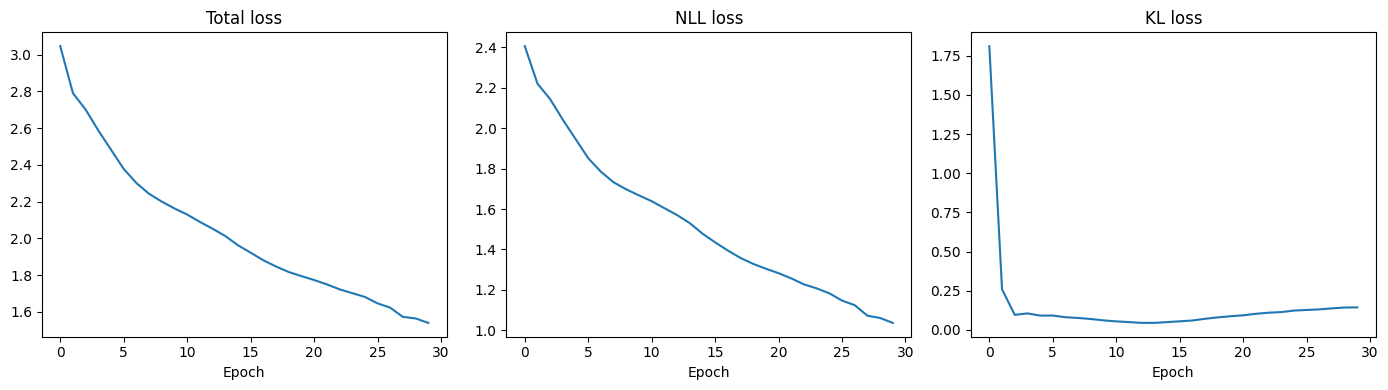

In [17]:
# TODO: Plot total, NLL, and KL loss curves
# YOUR CODE HERE
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(history['total']);     axes[0].set_title('Total loss')
axes[1].plot(history['nll']); axes[1].set_title('NLL loss')
axes[2].plot(history['kl']);        axes[2].set_title('KL loss')
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout(); plt.show()



## Step 4 -- Generate diverse completions

Generated 4 completions
Completion 0 length: 24 steps


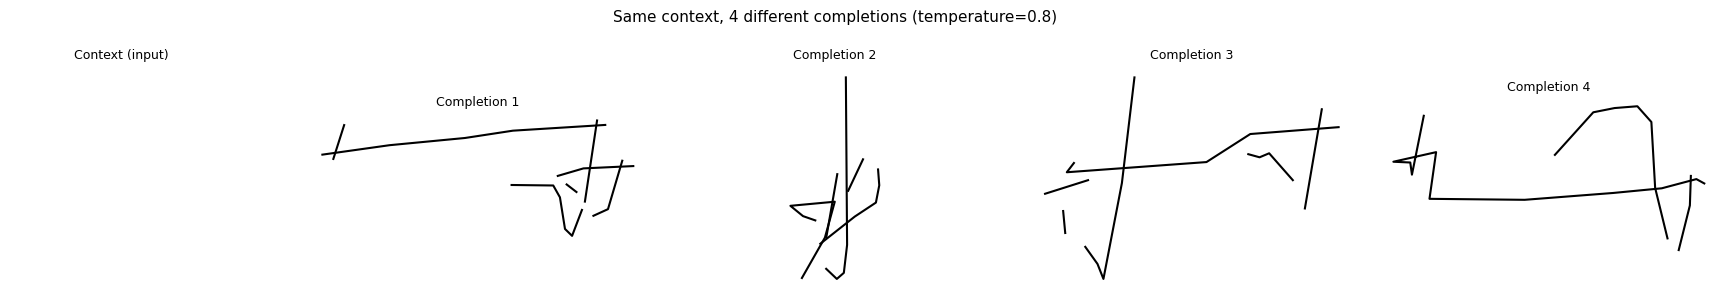

In [18]:
# TODO: Pick any sketch from your dataset.
#       Use the first third of it as context.
#       Generate 4 completions at temperature=0.8.
#       Plot them in a single row: context (blue) + 4 completions
# YOUR CODE HERE
def sample_mdn(params, temperature=1.0):
    '''
    Sample (dx, dy) from the mixture at each step.

    params      : dict of mixture parameters, each (batch, seq_len, K)
    temperature : controls randomness (0.1 = conservative, 1.0 = normal, 2.0 = wild)

    Returns:
        dx, dy : sampled positions, each shape (batch, seq_len)
    '''
    pi    = params['pi']    / temperature
    pi    = pi / pi.sum(dim=-1, keepdim=True)   # renormalise after temperature scaling
    mu_x  = params['mu_x']
    mu_y  = params['mu_y']
    sig_x = params['sig_x'] * temperature
    sig_y = params['sig_y'] * temperature
    rho   = params['rho']

    # Sample component index for each step
    batch, seq_len, K = pi.shape
    pi_flat = pi.reshape(-1, K)
    k_idx   = torch.multinomial(pi_flat, 1).squeeze(-1)   # (batch * seq_len,)
    k_idx   = k_idx.reshape(batch, seq_len)

    # Gather the parameters of the chosen component
    k_idx_exp = k_idx.unsqueeze(-1)
    mu_x_sel  = mu_x.gather(-1, k_idx_exp).squeeze(-1)
    mu_y_sel  = mu_y.gather(-1, k_idx_exp).squeeze(-1)
    sx        = sig_x.gather(-1, k_idx_exp).squeeze(-1)
    sy        = sig_y.gather(-1, k_idx_exp).squeeze(-1)
    r         = rho.gather(-1, k_idx_exp).squeeze(-1)

    # Sample from bivariate Gaussian
    eps_x = torch.randn_like(mu_x_sel)
    eps_y = torch.randn_like(mu_y_sel)
    dx = mu_x_sel + sx * eps_x
    dy = mu_y_sel + sy * (r * eps_x + torch.sqrt(1 - r**2) * eps_y)

    return dx, dy

def generate_completion(model, context, num_completions=4, max_len=150, temperature=0.8):
    '''
    Given a partial sketch (context), generate multiple completions.

    context         : tensor shape (1, context_len, 5)
    num_completions : how many diverse completions to generate
    temperature     : controls diversity
    '''
    model.eval()
    completions = []

    with torch.no_grad():
        for _ in range(num_completions):
            mu, logvar = model.encoder(context, [context.shape[1]])
            z = reparameterise(mu, logvar)   # each sample gives a slightly different z
            c_seq = model.conductor(z)

            # Start autoregressive generation from the last context step
            h, c_cell = None, None
            input_step = context[:, -1:, :]   # last known step
            generated = []

            seg_len = max_len // model.num_segments + 1
            c_exp   = c_seq.repeat_interleave(seg_len, dim=1)[:, :max_len, :]

            for t in range(max_len):
                c_t      = c_exp[:, t:t+1, :]
                worker_in = torch.cat([input_step, c_t], dim=-1)

                if h is None:
                    lstm_out, (h, c_cell) = model.worker.lstm(worker_in)
                else:
                    lstm_out, (h, c_cell) = model.worker.lstm(worker_in, (h, c_cell))

                mdn_p    = model.worker.mdn(lstm_out)
                pen_log  = model.worker.fc_pen(lstm_out)

                dx, dy   = sample_mdn(mdn_p, temperature=temperature)
                pen_state = F.softmax(pen_log.squeeze(1), dim=-1)
                pen_idx   = torch.multinomial(pen_state, 1)   # sample pen state
                pen_onehot = F.one_hot(pen_idx.squeeze(-1), num_classes=3).float()

                step = torch.cat([dx, dy, pen_onehot], dim=-1).unsqueeze(1)
                generated.append(step)
                input_step = step

                # Stop if EOS (p3=1)
                if pen_onehot[0, 2] == 1:
                    break

            completions.append(torch.cat(generated, dim=1).squeeze(0).cpu().numpy())

    return completions

# Test on one sketch
sample_sketch = dataset[0].unsqueeze(0).to(device)
context_len   = sample_sketch.shape[1] // 3   # use first third as context
context       = sample_sketch[:, :context_len, :]

completions = generate_completion(model, context, num_completions=4, temperature=0.8)
print(f'Generated {len(completions)} completions')
print(f'Completion 0 length: {completions[0].shape[0]} steps')

def stroke5_to_absolute(stroke5):
    abs_coords = np.cumsum(stroke5[:, :2], axis=0)
    pen_up = (stroke5[:, 3] + stroke5[:, 4]) > 0.5
    return abs_coords, pen_up

def plot_sketch5(stroke5_np, title='', color='black', ax=None):
    coords, pen_up = stroke5_to_absolute(stroke5_np)
    if ax is None: fig, ax = plt.subplots(figsize=(3,3))
    ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off'); ax.set_title(title, fontsize=9)
    start = 0
    for i in range(len(pen_up)):
        if pen_up[i]:
            seg = coords[start:i+1]
            ax.plot(seg[:,0], seg[:,1], color=color, linewidth=1.5)
            start = i+1

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
plot_sketch5(context.squeeze(0).cpu().numpy(), title='Context (input)', color='blue', ax=axes[0])
for i, comp in enumerate(completions):
    plot_sketch5(comp, title=f'Completion {i+1}', ax=axes[i+1])

plt.suptitle('Same context, 4 different completions (temperature=0.8)', fontsize=11)
plt.tight_layout(); plt.show()



## Step 5 -- Temperature experiment

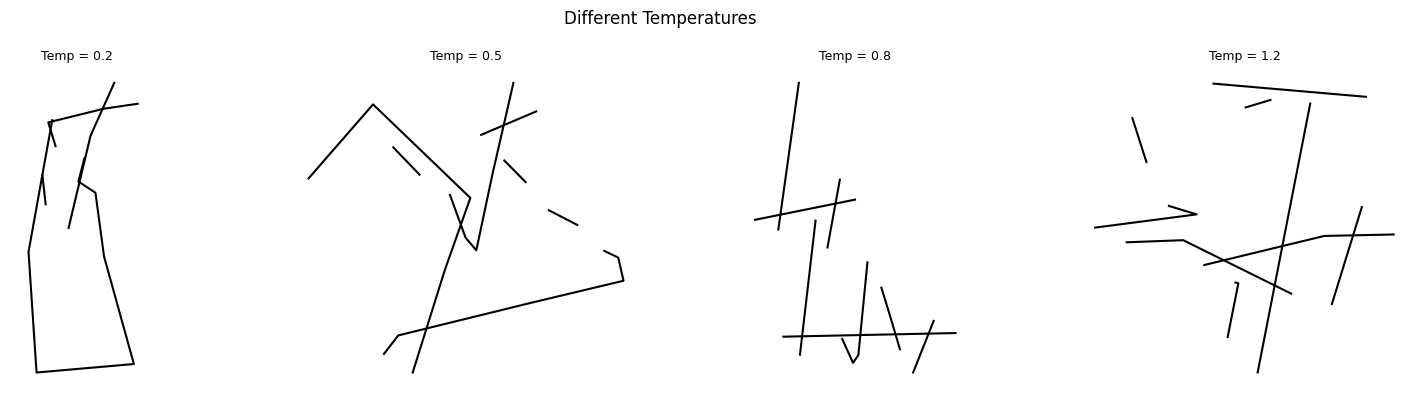

In [ ]:
# TODO: Pick the same context sketch.
#       Generate one completion at each of these temperatures: 0.2, 0.5, 0.8, 1.2
#       Plot all 4 in a row and comment on what you observe.
# YOUR CODE HERE
# Generate completions at different temperatures
temperatures = [0.2, 0.5, 0.8, 1.2]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, temp in enumerate(temperatures):
    completion = generate_completion(model, context, num_completions=1, temperature=temp)[0]
    plot_sketch5(completion, title=f'Temp = {temp}', ax=axes[i])
plt.suptitle('Different Temperatures', fontsize=12)
plt.tight_layout()
plt.show()

# At temperature (0.2), the sketch is more stable and predictable.
# At temperatures (0.5 and 0.8), the completions are more natural and varied.
# At temperature (1.2), the sketch becomes more random and less accurate.


## Step 6 -- Reflection questions

In [20]:
# Q1: Why does the MDN produce better outputs than the MSE-based decoder?
#     What specific failure mode does MSE cause for sequence generation?
# MDN can predict multiple possible outputs, so the sketches look more natural.
# MSE tries to find an average, so the sketch can look unclear.

# Q2: What does temperature control physically in the MDN sampling?
#     What happens at temperature -> 0? At temperature -> infinity?
# Temperature controls how random the sketch is.
# Low temperature gives more predictable results, and high temperature gives more random results.

# Q3: Do your 4 completions look meaningfully different from each other?
#     If they all look the same, what might be going wrong?
# Yes, the completions should look a little different from each other.
# If they all look the same, the model is not creating different outputs.
# model not using temperature properly.

# Q4: The model was trained with teacher forcing but generates autoregressively.
#     What problems can this cause, and how might you address them?
# During training the model gets the correct previous stroke.
# During generation it uses its own stroke, so mistakes can increase over time.

# YOUR ANSWERS HERE


## Bonus (optional)
- Try num_mixtures = 5 vs 50. How does it affect diversity and quality?
- Morph between two sketches by interpolating their z vectors and generating completions at each interpolation step

## Submission checklist

- [ ] HierarchicalMDNVAE trained 20+ epochs
- [ ] NLL, pen, KL loss curves plotted
- [ ] 4 diverse completions from same context plotted
- [ ] Temperature experiment (4 temperatures) plotted
- [ ] All 4 reflection questions answered